# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA & DLinear 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1. 시계열 데이터가 정상성을 만족하지 않는다면, 모델이 잘못된 패턴을 학습하여 예측 성능에 큰 영향을 미칠 수 있다. 이를 해결하기 위해 ARIMA 모델은 차분을 사용한다

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2.
ARIMA(0,1,1)

## 실습

- 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)입니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [3]:
# 1) kaggle 설치
!pip -q install kaggle

# 2) kaggle.json 업로드
from google.colab import files
files.upload()  # 여기서 kaggle.json 선택

# 3) 경로 이동 + 권한 설정
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [4]:
!kaggle datasets download -d smid80/weatherww2 -p /content --force
!ls -lh /content | tail

Dataset URL: https://www.kaggle.com/datasets/smid80/weatherww2
License(s): U.S. Government Works
  0% 0.00/1.65M [00:00<?, ?B/s]
100% 1.65M/1.65M [00:00<00:00, 313MB/s]
total 1.7M
-rw-r--r-- 1 root root   69 Mar  5 06:07 kaggle.json
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data
-rw-r--r-- 1 root root 1.7M Sep 21  2019 weatherww2.zip


In [5]:
!unzip -q /content/weatherww2.zip -d /content/weatherww2
!find /content/weatherww2 -maxdepth 2 -type f | head

/content/weatherww2/Weather Station Locations.csv
/content/weatherww2/Summary of Weather.csv


In [6]:
# kaggle 데이터 로드
import os

path = "/kaggle/input/weatherww2"
print(os.listdir(path))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/weatherww2'

In [7]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_df = pd.read_csv("/content/weatherww2/Weather Station Locations.csv")
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [8]:
# station별 실제 날씨 데이터
weather_df = pd.read_csv("/content/weatherww2/Summary of Weather.csv")

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 를 수치형 값(ex.0.1, 0.01)으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_1680/696293649.py:2: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv("/content/weatherww2/Summary of Weather.csv")


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [9]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_1680/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_1680/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


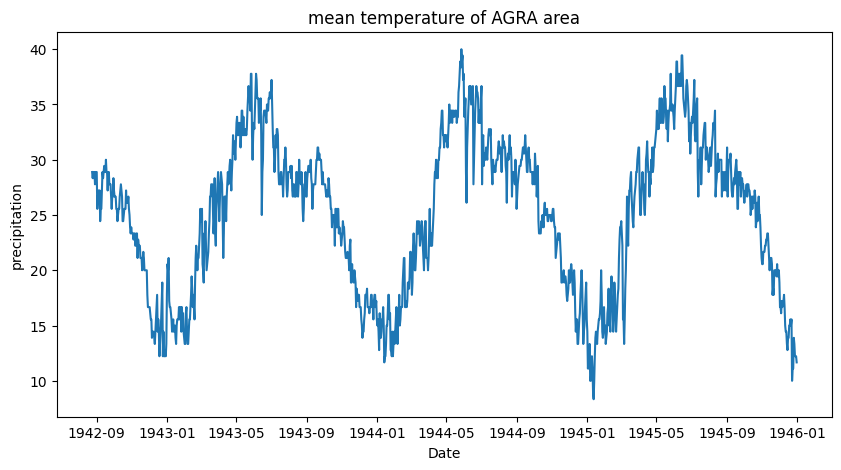

In [10]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [11]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

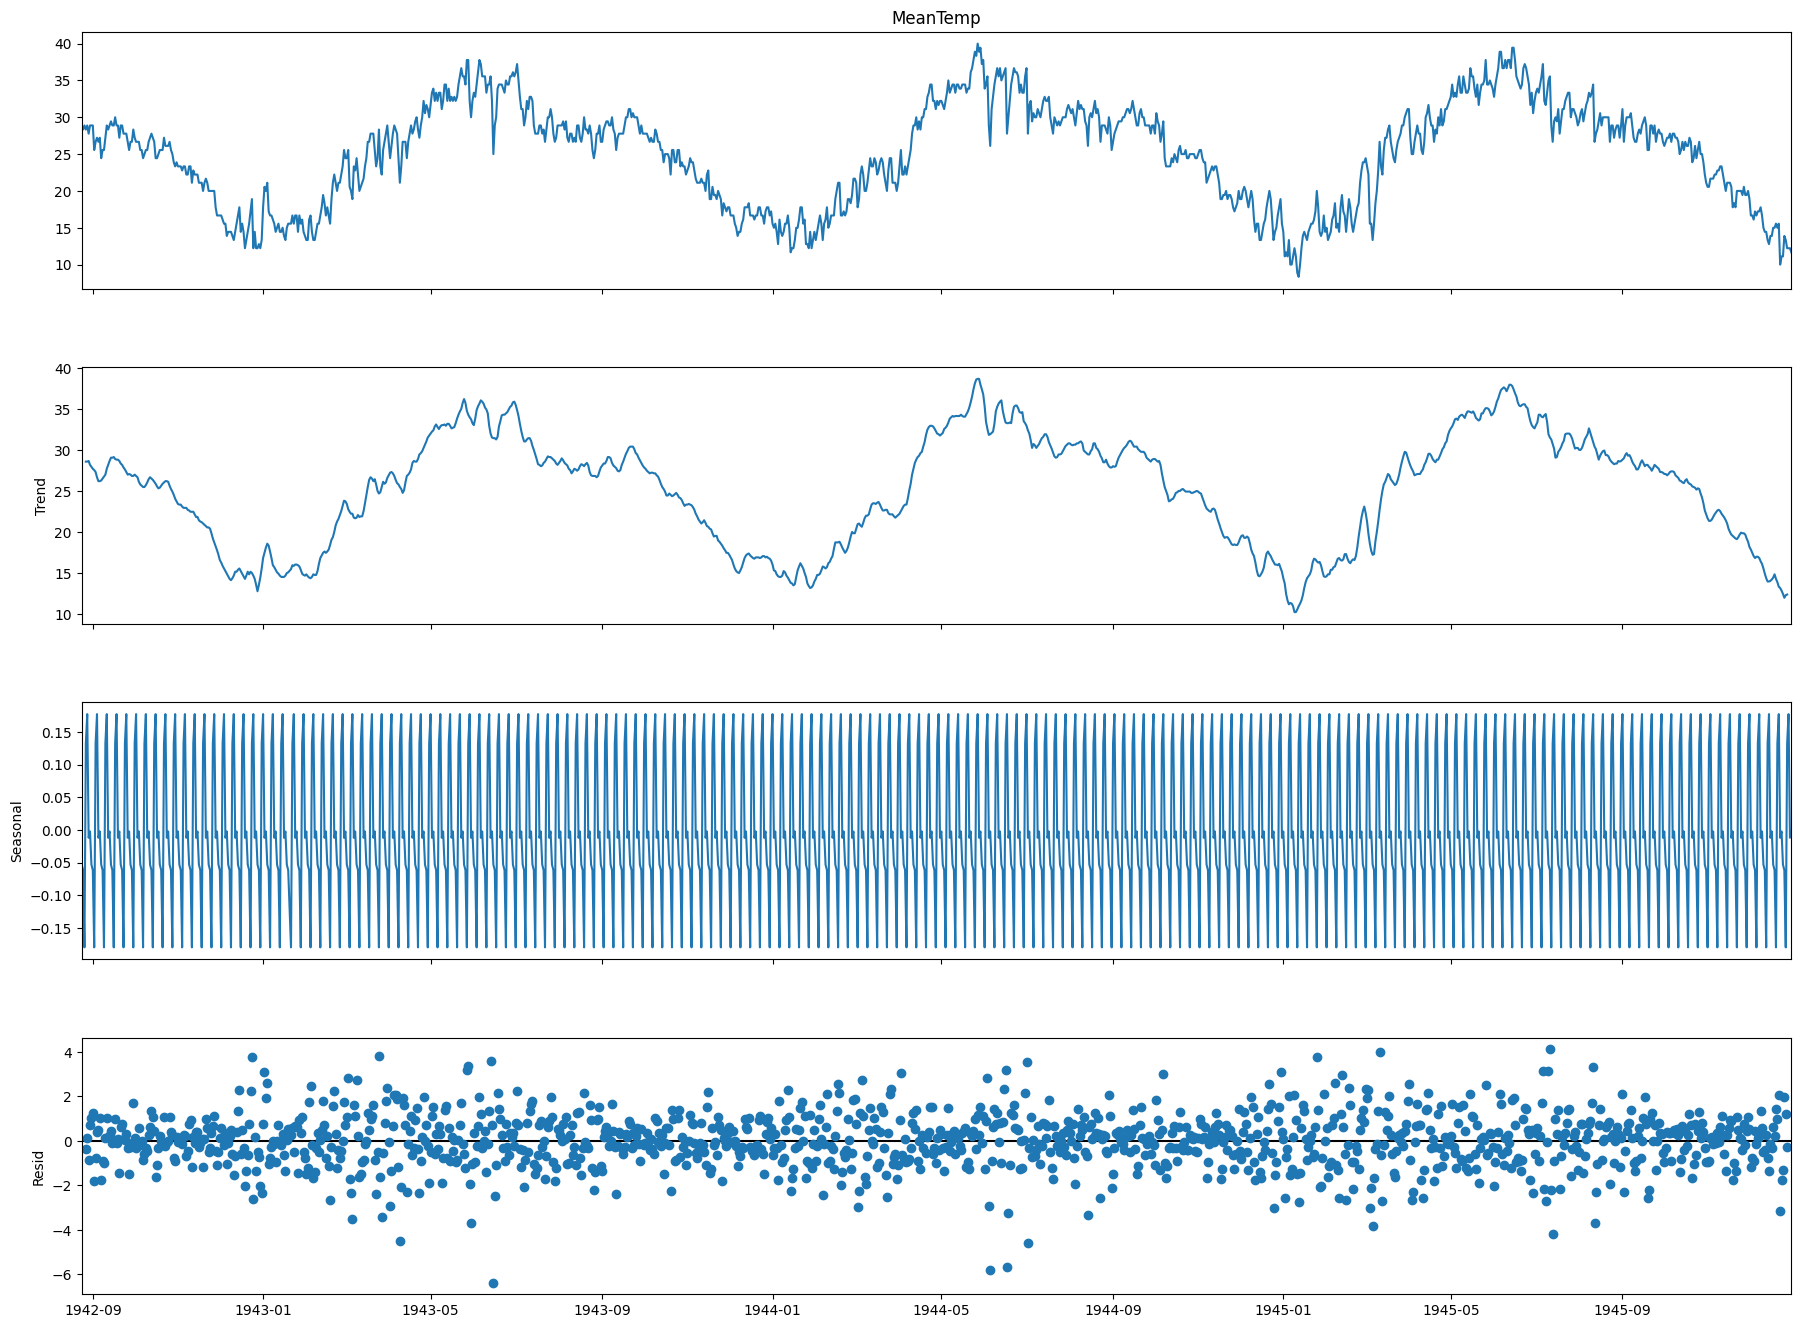

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

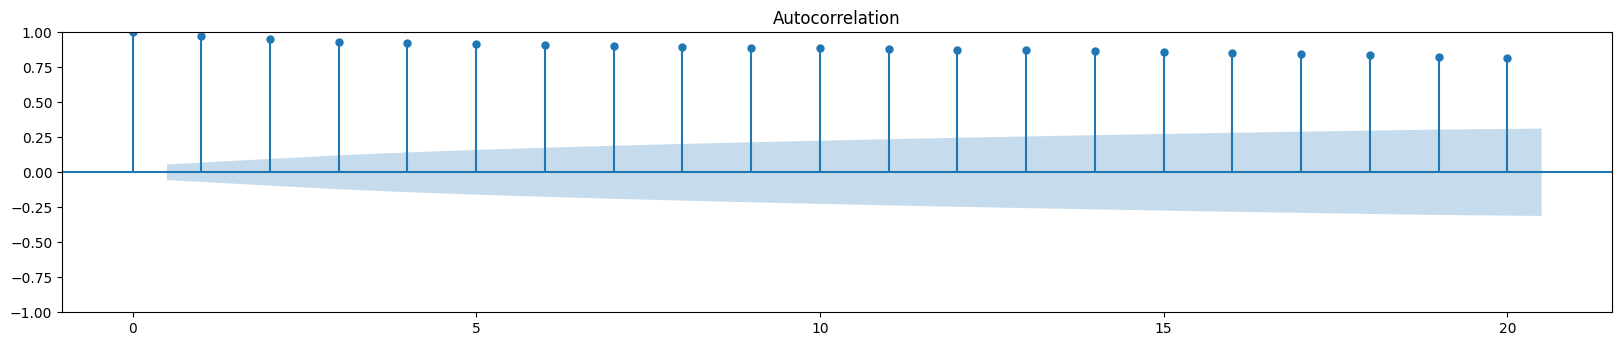

In [13]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [14]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설 혹은 귀무가설이라는 키워드를 사용하여 서술하세요.

A1.
H0 : 해당 시계열은 비정상이다.

H1 : 해당 시계열은 정상이다.

p value가 0.26으로 일반적인 유의수준보다 크므로 귀무가설을 기각할 수 없다.

따라서 해당 시계열은 비정상성이라고 판단하고, 차분이 필요하다

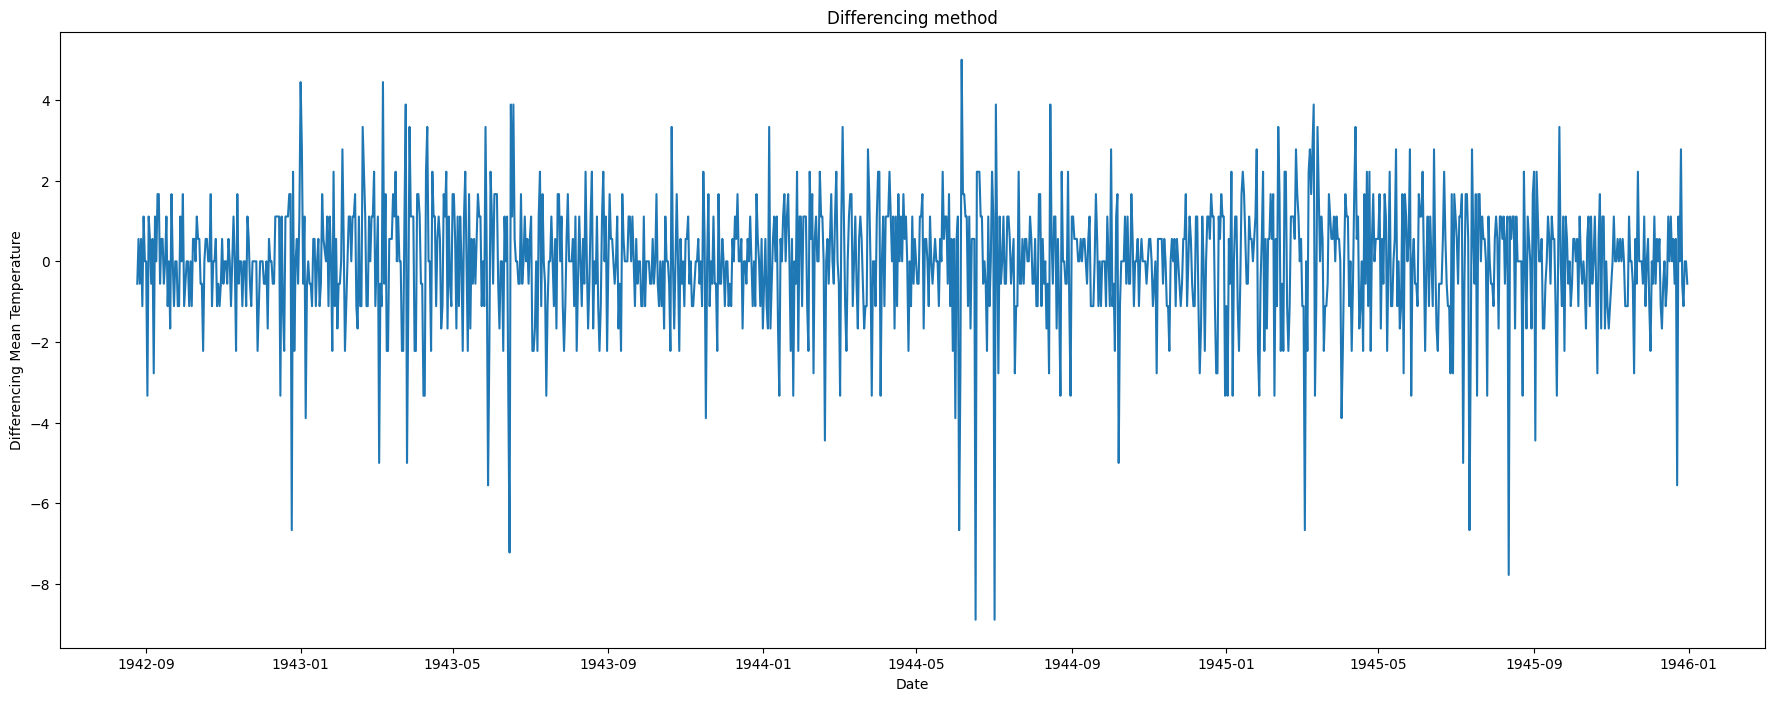

In [15]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [16]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2.

*   차분을 진행하였다
*   귀무가설을 기각할 정도의 p value가 나왔으므로 귀무가설 기각, 해당 시계열은 정상 시계열이라고 판단한다.



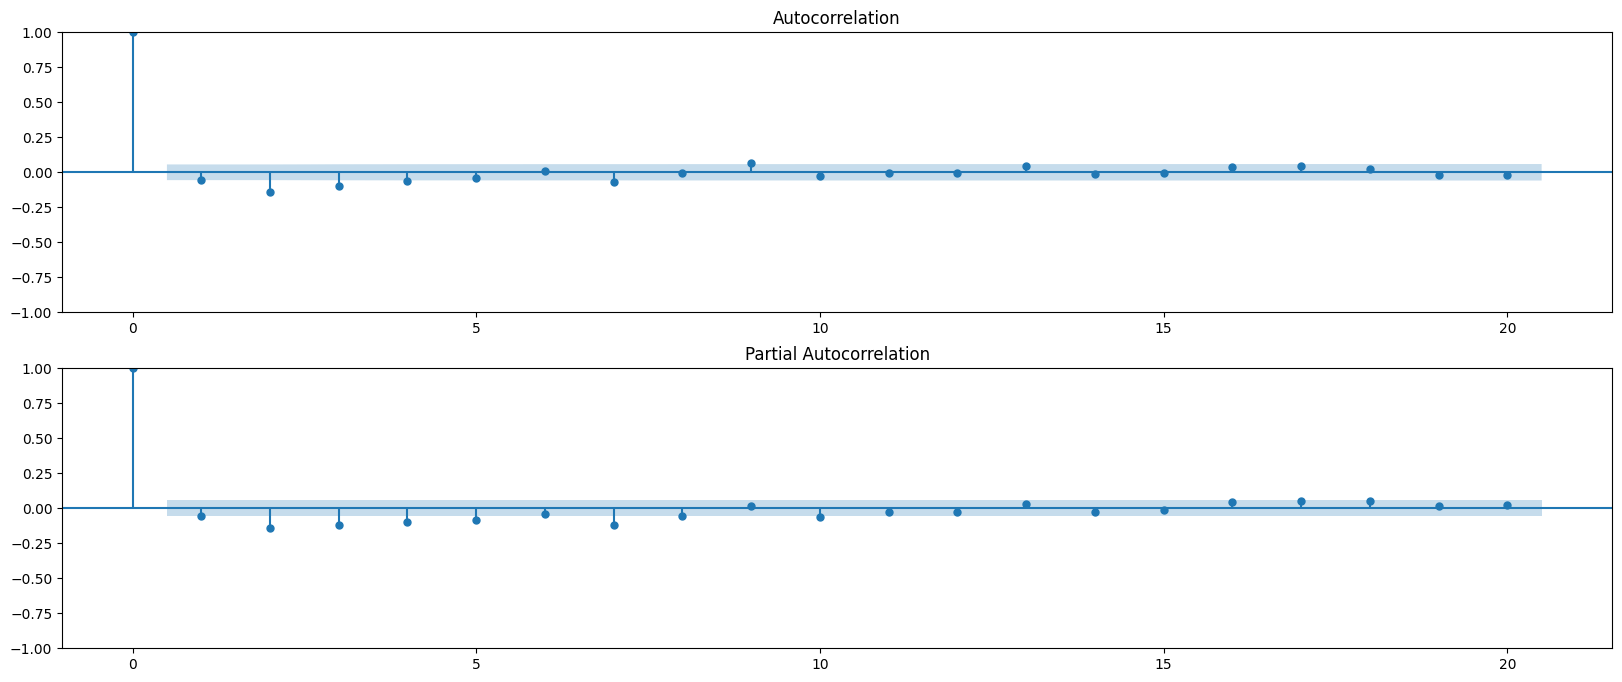

In [17]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3.
파란색 범위 내에 있는 lag는 유의미하게 영향을 주지 않는다는 뜻이다.
주로 ACF는 MA(q)의 차수 판단에, PACF는 MA(p) 차수 판단에 도움을 준다.
해당 그림을 보면 lag1의 영향이 가장 크므로
p=1, q=1로 설정하는 것이 합리적이다



### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


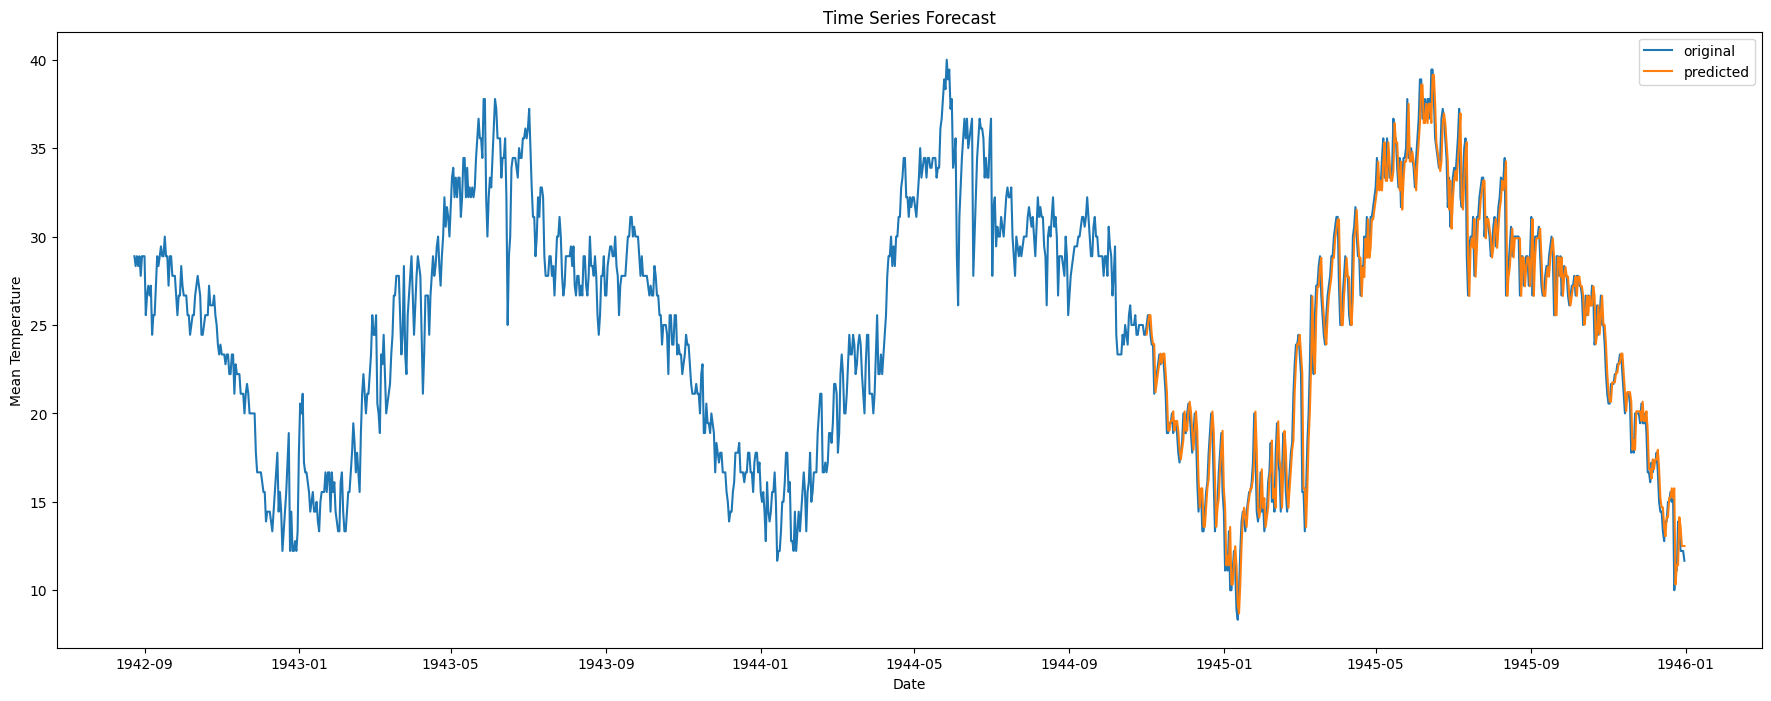

In [18]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 1
d = 1
q = 1

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_1680/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


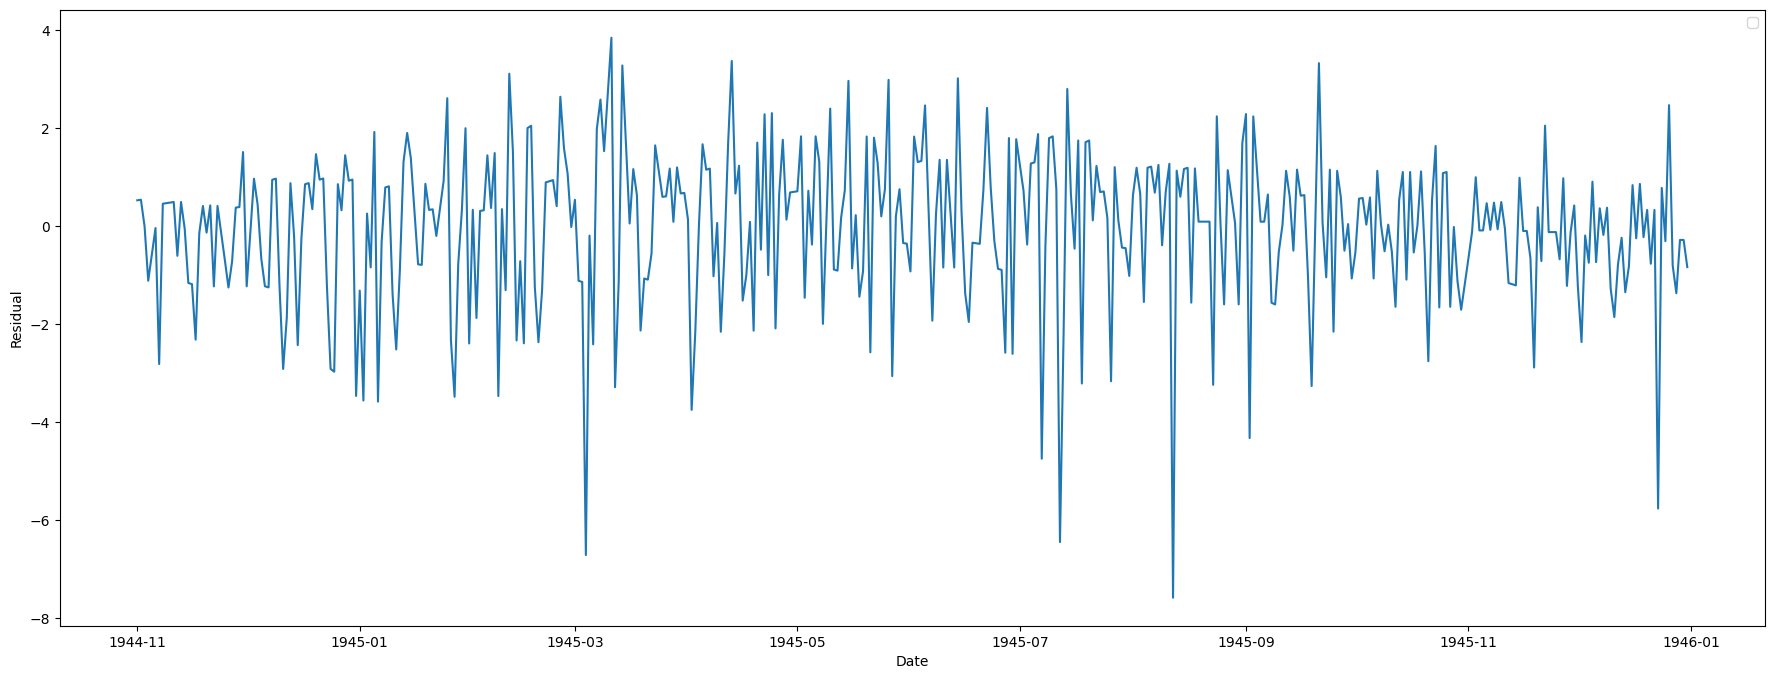

In [19]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

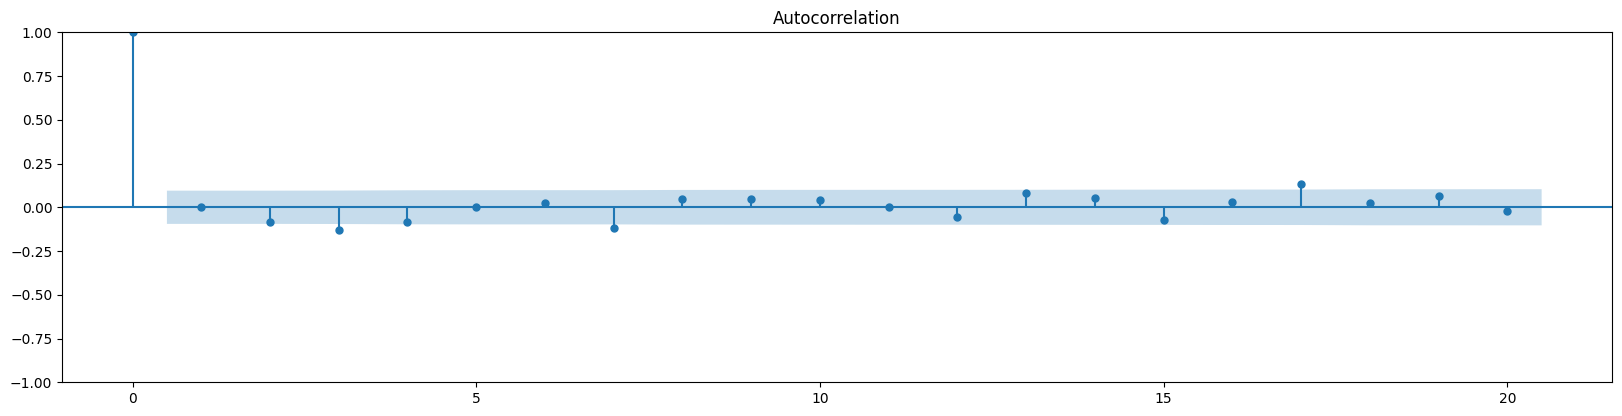

In [20]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [21]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.899484
p-value: 0.002039
Critical Values:
	1%: -3.446
	5%: -2.869
	10%: -2.571


In [22]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [23]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.589,0.978,1.56,5.426


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4.

p value가 매우 작으므로 해당 시계열은 정상 시계열의 경향을 보여주고, 해당 모델이 타킷 변동의 약 95.6%를 설명한다. 설명력이 매우 크다

### DLinear
Q4. DLinear 모델은 kernel, learning rate, epoch 등 여러 하이퍼파라미터가 존재합니다. 아래 코드에서 각 하이퍼파라미터를 직접 조정하시며 가장 좋은 결과가 나온 값을 작성해주세요. 또한 그 값이 좋은 결과라고 판단하게 된 근거를 작성해주세요. (ex. 에러율, 시각화 결과 등) 마지막으로, ARIMA와 비교하여 해당 데이터셋에서는 어느 모델이 더 적합한 것 같은지 모델의 이름과 그 이유를 작성해주세요.

A4.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
data = ts.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [25]:
seq_len = 365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [26]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=365):
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [27]:
model = DLinear(seq_len, pred_len).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 10

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.008974


In [28]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)

while len(predictions) < total_test_len:

  x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

  with torch.no_grad():
    pred = model(x).cpu().numpy().flatten()

  # 남은 길이보다 많이 예측했으면 자르기
  remaining = total_test_len - len(predictions)
  pred = pred[:remaining]

  predictions.extend(pred)

  # window 업데이트 (예측값 붙이고 앞에서 제거)
  current_window = np.concatenate(
    [current_window[pred_len:], pred.reshape(-1,1)],
    axis=0
  )

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

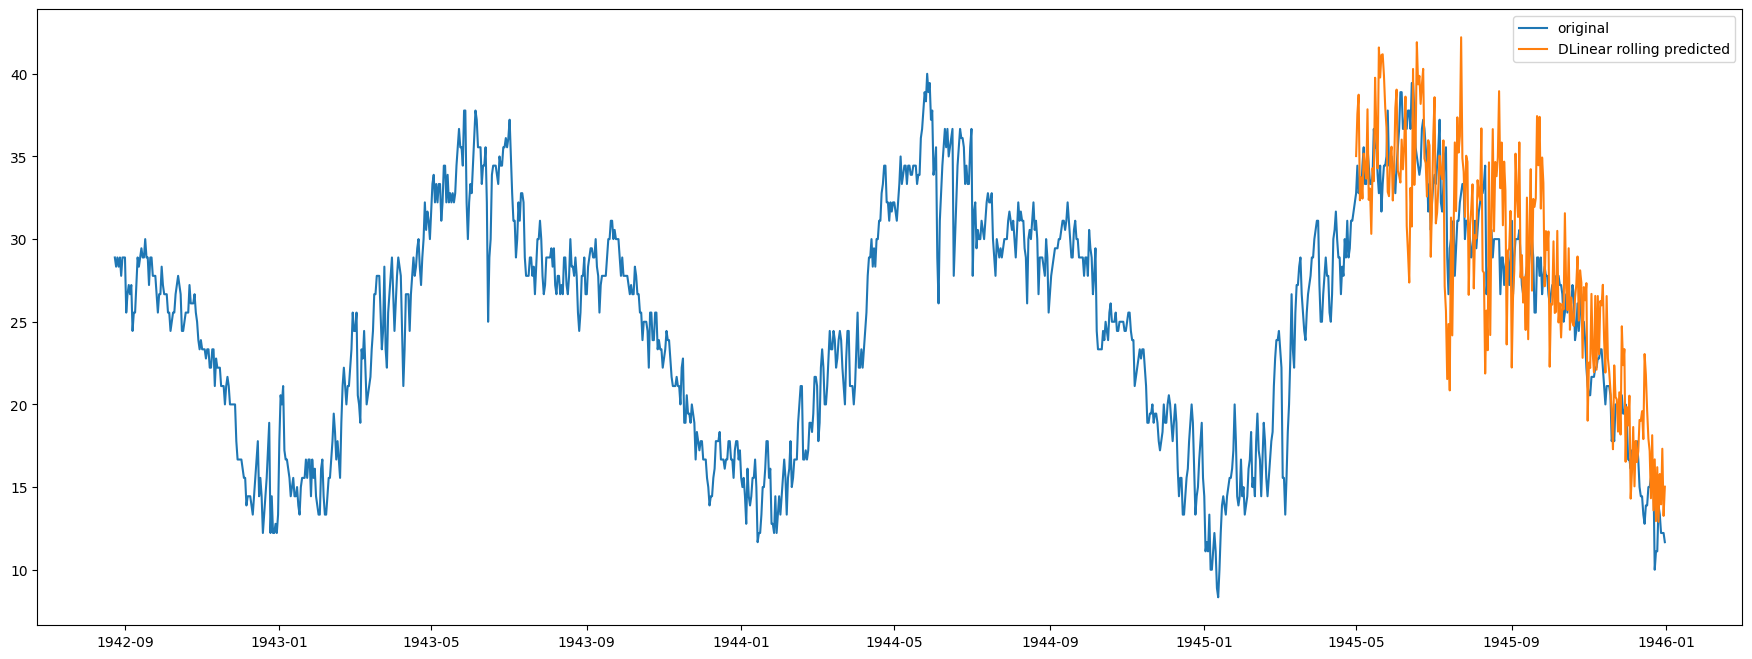

In [29]:
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values, label="original")

test_dates = ts.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [30]:
test_start_idx = train_size

y_true = ts.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(245,) (245,)


,R2,Corr,RMSE,MAPE
0,65.411,0.844,4.06,12.588


## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

-> 뭔가 강수량 관련 분석같은데 MeanTemp에 관련된 시계열 같아서 온도로 진행

In [31]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

,0
NAME,
ACCRA,1157
AGRA,1225
AMBERLY,848
AMURI/FIELD AAF,884
ATAR,876
...,...
TINDOUF,818
VAL DE CANS,1188
WALLER/BWI,1631


In [34]:
# 도시 선택
CITY = "AIN EL"
city_df = merged[merged["NAME"] == CITY].copy()

print(city_df.shape)
city_df.head()

(383, 8)


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip,WBAN,NAME
79448,33013,1943-3-11,15.555556,2.777778,8.888889,0.0,33013,AIN EL
79449,33013,1943-3-12,12.777778,4.444444,8.888889,0.0,33013,AIN EL
79450,33013,1943-3-13,17.222222,2.777778,10.000000,0.0,33013,AIN EL
79451,33013,1943-3-14,10.000000,7.222222,8.888889,0.0,33013,AIN EL
79452,33013,1943-3-15,14.444444,5.555556,10.000000,0.0,33013,AIN EL


In [35]:
# 도시 선택
CITY = "AIN EL"
city_df = merged[merged["NAME"] == CITY].copy()

print(city_df.shape)
city_df.head()

(383, 8)


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip,WBAN,NAME
79448,33013,1943-3-11,15.555556,2.777778,8.888889,0.0,33013,AIN EL
79449,33013,1943-3-12,12.777778,4.444444,8.888889,0.0,33013,AIN EL
79450,33013,1943-3-13,17.222222,2.777778,10.000000,0.0,33013,AIN EL
79451,33013,1943-3-14,10.000000,7.222222,8.888889,0.0,33013,AIN EL
79452,33013,1943-3-15,14.444444,5.555556,10.000000,0.0,33013,AIN EL


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

In [37]:
CITY = "AIN EL"
TARGET_COL = "MeanTemp"
DATE_COL = "Date"

city_df = merged[merged["NAME"] == CITY].copy()
city_df[DATE_COL] = pd.to_datetime(city_df[DATE_COL])
city_df = city_df.sort_values(DATE_COL)

# 일별 MeanTemp 시계열
ts_daily = (city_df.set_index(DATE_COL)[TARGET_COL]
            .astype(float)
            .sort_index()
            .dropna())

# 월별 평균기온(MeanTemp는 합이 아니라 평균이 자연스러움)
ts = ts_daily.resample("M").mean()

print(ts.head())
print("n_obs:", len(ts))

Date
1943-03-31    10.820106
1943-04-30          NaN
1943-05-31    16.738351
1943-06-30          NaN
1943-07-31          NaN
Freq: ME, Name: MeanTemp, dtype: float64
n_obs: 22


/tmp/ipykernel_1680/390931715.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = ts_daily.resample("M").mean()


In [46]:
import numpy as np

# ✅ 일 단위로 빈 날짜 채우기(없던 날짜는 NaN으로 생성됨)
ts = ts_daily.asfreq("D")

# ✅ 이상값 처리 + 결측 보간(MeanTemp는 선형보간 OK)
ts = ts.replace([np.inf, -np.inf], np.nan)
ts = ts.interpolate(method="time")   # 시간축 기준 보간
ts = ts.dropna()

print(ts.head())
print("n_obs(daily):", len(ts))
print("date range:", ts.index.min(), "~", ts.index.max())

Date
1943-03-11     8.888889
1943-03-12     8.888889
1943-03-13    10.000000
1943-03-14     8.888889
1943-03-15    10.000000
Freq: D, Name: MeanTemp, dtype: float64
n_obs(daily): 635
date range: 1943-03-11 00:00:00 ~ 1944-12-04 00:00:00


In [47]:
data = ts.values.astype(float)

train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]
test_index = ts.index[train_size:]   # 예측 시각화용

print("train:", len(train), "test:", len(test))

train: 508 test: 127


In [48]:
from statsmodels.tsa.stattools import adfuller

def adf_pvalue(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return adfuller(x)[1]

d = 0
tmp = train.copy()

while d < 2 and adf_pvalue(tmp) > 0.05:
    tmp = np.diff(tmp)
    d += 1

print("Selected d =", d, "| ADF p-value(after diff) =", adf_pvalue(tmp))

Selected d = 1 | ADF p-value(after diff) = 6.910578672747982e-21


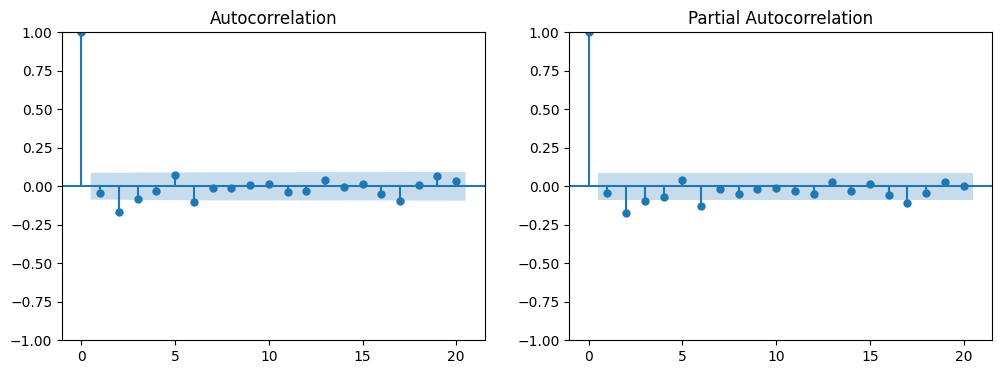

n(after diff) = 507 | L_acf = 20 | L_pacf = 20


In [49]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series_for_plot = train.copy()
for _ in range(d):
    series_for_plot = np.diff(series_for_plot)

series_for_plot = series_for_plot[np.isfinite(series_for_plot)]
n = len(series_for_plot)

L_acf  = min(20, n - 1)
L_pacf = min(20, (n // 2) - 1)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
plot_acf(series_for_plot, lags=L_acf, ax=ax[0])
plot_pacf(series_for_plot, lags=max(1, L_pacf), ax=ax[1], method="ywm")
plt.show()

print("n(after diff) =", n, "| L_acf =", L_acf, "| L_pacf =", L_pacf)

In [50]:
from statsmodels.tsa.arima.model import ARIMA

best_aic = float("inf")
best_order = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            fit = ARIMA(train, order=(p, d, q)).fit()
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p, d, q)
        except:
            pass

print("Best order:", best_order, "| AIC:", best_aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Best order: (2, 1, 2) | AIC: 1943.9886869738705


In [52]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import numpy as np

p, d, q = best_order
fit = ARIMA(train, order=(p, d, q)).fit()
pred = fit.forecast(steps=len(test))

r2 = r2_score(test, pred)

mse = mean_squared_error(test, pred)   # squared 인자 없이 MSE만 계산
rmse = np.sqrt(mse)                    # ✅ RMSE는 루트 씌우기

mape = mean_absolute_percentage_error(test, pred) * 100
corr = np.corrcoef(test, pred)[0, 1]

print({"R2": r2, "Corr": corr, "RMSE": rmse, "MAPE(%)": mape})

{'R2': -0.9292639368571454, 'Corr': np.float64(-0.24743411149269873), 'RMSE': np.float64(10.442763273824962), 'MAPE(%)': 76.3444971892858}


AIN EL의 일별 MeanTemp에 대해 현재 ARIMA 모델은 R²가 -0.93, Corr가 -0.25로, 평균 예측보다도 못 맞추는 수준이라 패턴을 제대로 학습하지 못했다고 볼 수 있다